In [1]:
# Install the transformer in your colab

!pip install transformers

In [2]:
# Installing huggingface hub
!pip install huggingface_hub

In [3]:
# Huggingface login

from huggingface_hub import notebook_login
notebook_login()

In [4]:
# Load a pre-trained llm

from transformers import AutoTokenizer, AutoModelForCausalLM

model = "mistralai/Mistral-7B-Instruct-v0.1"
tokenizer = AutoTokenizer.from_pretrained(model)
model = AutoModelForCausalLM.from_pretrained(model)

print("Tokenizer:\n", tokenizer)
print("Model:\n", model)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  493kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Tokenizer:
 TokenizersBackend(name_or_path='mistralai/Mistral-7B-Instruct-v0.1', vocab_size=32000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>'}, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})
Model:
 MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_featur

In [5]:
# Zero-shot prompt
prompt = "Summarize the importance of robotics in education in three sentences."

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(**inputs,max_new_tokens=200,
)

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("Zero-Shot Output:\n", response)

Zero-Shot Output:
 Summarize the importance of robotics in education in three sentences.

1. Robotics in education helps students to develop critical thinking and problem-solving skills as they learn to design, build, and program robots.
2. It also encourages creativity and innovation, and provides hands-on learning experiences that can enhance student engagement and motivation.
3. Furthermore, robotics in education can help to prepare students for future careers in STEM fields, as they gain a deeper understanding of programming, engineering, and mathematics concepts.


In [6]:
# Few - shot prompt

few_shot_prompt = """Summarize Robotics in three sentences.

Topic: Artificial Intelligence
Summary: Artificial intelligence enables machines to perform tasks that normally require human intelligence. It is widely used in healthcare, finance, and education. AI continues to evolve, raising both opportunities and ethical challenges.

Topic: Machine Learning
Summary: Machine learning is a subset of AI that allows systems to learn from data. It powers applications like recommendation systems and fraud detection. ML improves performance over time without explicit programming.

Topic: Robotics
Summary:"""


inputs = tokenizer(few_shot_prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=200
)

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("Few shot output\n",response)

Few shot output
 Summarize Robotics in three sentences.

Topic: Artificial Intelligence
Summary: Artificial intelligence enables machines to perform tasks that normally require human intelligence. It is widely used in healthcare, finance, and education. AI continues to evolve, raising both opportunities and ethical challenges.

Topic: Machine Learning
Summary: Machine learning is a subset of AI that allows systems to learn from data. It powers applications like recommendation systems and fraud detection. ML improves performance over time without explicit programming.

Topic: Robotics
Summary: Robotics combines AI and mechanical engineering to create machines that can interact with the physical world. Robots are used in manufacturing, transportation, and space exploration. They have the potential to revolutionize industries and improve human lives.


In [ ]:
prompt = """
Translate the following sentences into French:

English: "The teacher explains machine learning concepts."
French: "Le professeur explique les concepts d'apprentissage automatique."

English: "The students are designing a robot in class."
French: "Les étudiants conçoivent un robot en classe."

English: "The students are building a robot using Python and Arduino."
French:
"""

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=200,

)

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("Few shot output\n",response)

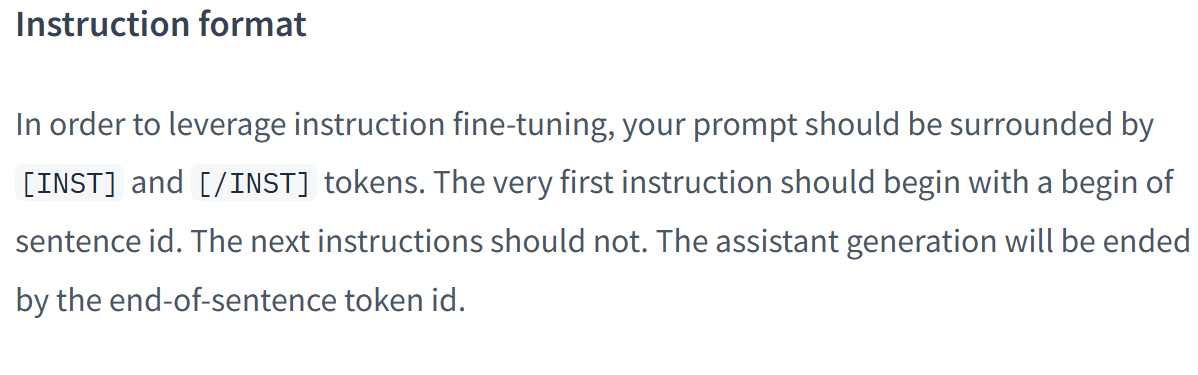

In [8]:
# 🔹 System vs User Prompt
# System Prompt: Sets the overall role, style, or constraints for the model. Think of it as the "persona" or "rules of engagement."
# User Prompt: The actual task or query you want answered.

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

def chat(system_prompt, user_prompt, max_new_tokens=200):
    # Combine system + user prompt
    full_prompt = f"<s>[SYSTEM] {system_prompt}\n[USER] {user_prompt}\n[ASSISTANT]"
    inputs = tokenizer(full_prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# -----------------------------
# Zero-Shot Example
# -----------------------------
system_prompt = "You are a helpful assistant that explains concepts clearly."
user_prompt = "Summarize the importance of robotics in education in three sentences."
print("Zero-Shot:\n", chat(system_prompt, user_prompt))

# -----------------------------
# Few-Shot Example
# -----------------------------
system_prompt = "You are a helpful assistant that summarizes topics in three sentences."
user_prompt = """Topic: Artificial Intelligence
Summary: Artificial intelligence enables machines to perform tasks that normally require human intelligence. It is widely used in healthcare, finance, and education. AI continues to evolve, raising both opportunities and ethical challenges.

Topic: Machine Learning
Summary: Machine learning is a subset of AI that allows systems to learn from data. It powers applications like recommendation systems and fraud detection. ML improves performance over time without explicit programming.

Topic: Robotics
Summary:"""

print("\nFew-Shot:\n", chat(system_prompt, user_prompt))

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Zero-Shot:
 [SYSTEM] You are a helpful assistant that explains concepts clearly.
[USER] Summarize the importance of robotics in education in three sentences.
[ASSISTANT] Robotics in education is important because it helps students to develop critical thinking and problem-solving skills, encourages creativity and innovation, and prepares them for future careers in STEM fields. Through hands-on learning experiences, students can gain a better understanding of complex concepts and improve their analytical and decision-making abilities. Additionally, robotics in education can help to increase student engagement and motivation, making learning more enjoyable and effective.

Few-Shot:
 [SYSTEM] You are a helpful assistant that summarizes topics in three sentences.
[USER] Topic: Artificial Intelligence
Summary: Artificial intelligence enables machines to perform tasks that normally require human intelligence. It is widely used in healthcare, finance, and education. AI continues to evolve, rai

#**COT**

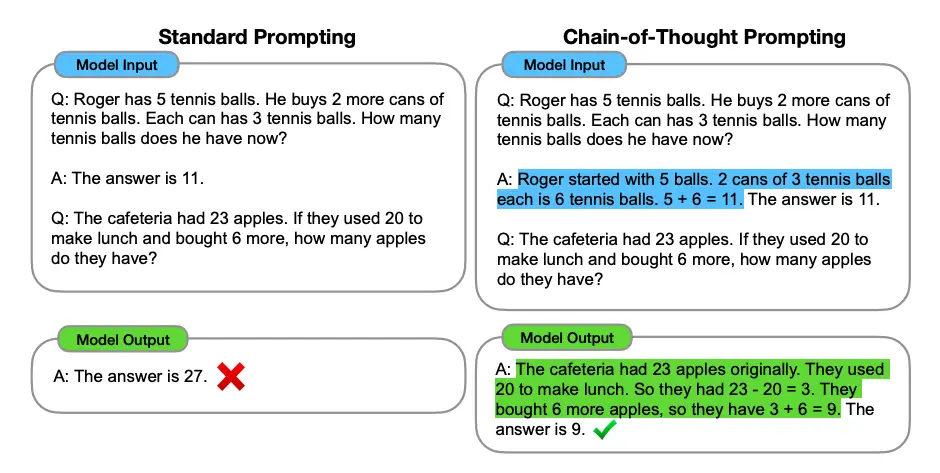

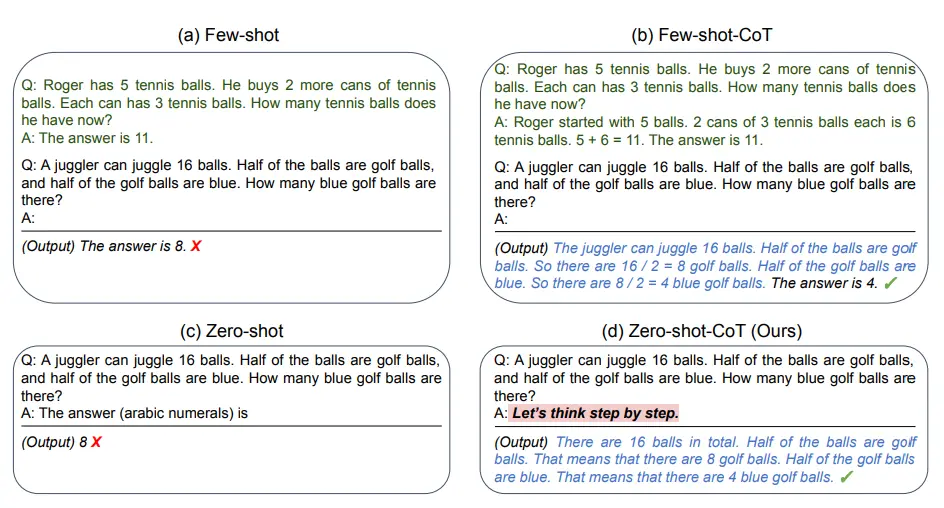

The Chain-of-Thought (CoT) Prompting Technique is all about explicitly guiding the model to show its reasoning process step by step before giving the final answer. Let’s unpack it using your odd-number example.


In [9]:
# Load Model and tokenizer

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [10]:
# Zero shot COT prompting

prompt = '''
Answer the following question step by step.

Question: If a class has 24 studends and each student brings 3 notebook and 5 pens, how many notebooks and pens are in the class?

Let's think step by step.
'''

In [11]:
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs, max_new_tokens=512)
print(tokenizer.decode(output[0], skip_special_tokens=True))


Answer the following question step by step.

Question: If a class has 24 studends and each student brings 3 notebook and 5 pens, how many notebooks and pens are in the class?

Let's think step by step.

1. We know that each student brings 3 notebooks. So, to find out how many notebooks are in total, we multiply the number of students by the number of notebooks each student brings.

Total Notebooks = Number of Students × Notebooks per Student
Total Notebooks = 24 × 3
Total Notebooks = 72

2. Similarly, each student also brings 5 pens. To find out how many pens are in total, we multiply the number of students by the number of pens each student brings.

Total Pens = Number of Students × Pens per Student
Total Pens = 24 × 5
Total Pens = 120

So, there are 72 notebooks and 120 pens in the class.


In [12]:
prompt='''Answer the following question step by step based on given examples.

Question: A pack has 10 pencils. If you buy 5 packs, how many pencils total?
Answer: Each pack has 10 pencils.
You buy 5 packs.
Total pencils = 10 × 5 = 50.

Q: A box has 8 chocolates. If you buy 7 boxes, how many chocolates total?
A: Each box has 8 chocolates.
You buy 7 boxes.
Total chocolates = 8 × 7 = 56.

Q: A class has 24 students and each brings 3 notebooks. How many notebooks total?
A:'''

In [13]:
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs)
print(tokenizer.decode(output[0], skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1625: UserWarning: Using the model-agnostic default `max_length` (=191) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Answer the following question step by step based on given examples.

Question: A pack has 10 pencils. If you buy 5 packs, how many pencils total?
Answer: Each pack has 10 pencils.
You buy 5 packs.
Total pencils = 10 × 5 = 50.

Q: A box has 8 chocolates. If you buy 7 boxes, how many chocolates total?
A: Each box has 8 chocolates.
You buy 7 boxes.
Total chocolates = 8 × 7 = 56.

Q: A class has 24 students and each brings 3 notebooks. How many notebooks total?
A: Each student brings 3 notebooks.
There are 24 students.
Total notebooks


In [14]:
# Zero shot COT prompting

prompt = '''
Answer the following question step by step.

Question: If a class has 24 studends and each student brings 3 notebook and 5 pens, how many notebooks and pens are in the class?

Let's think step by step. Before you start solving list the thinking steps that you have.
'''

In [16]:
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs)
print(tokenizer.decode(output[0], skip_special_tokens=True))


Answer the following question step by step.

Question: If a class has 24 studends and each student brings 3 notebook and 5 pens, how many notebooks and pens are in the class?

Let's think step by step. Before you start solving list the thinking steps that you have.

1. We know that each student brings 3 notebooks and 5 pens.
2


### 1. **Instructional Prompting**
- **What it means**

- Instructional prompting focuses on telling the model: What task to perform and what output to produce. It is goal-oriented and instruction-driven. You treat the model like a tool.

### 2. Role-Based Prompting
- **What it means**

Role-based prompting assigns a persona or expert identity to the model.

You tell the model: “Act as…”. This changes tone, depth, and style of response.

- Structure

    - You are a [role/persona].
    - Your task is to…
    - Follow these constraints…

In [17]:
prompt = '''
Role: You are a cybersecurity expert.
Task: Explain phishing attacks to non-technical users.
'''

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs, max_new_tokens=250)
print(tokenizer.decode(output[0], skip_special_tokens=True))


Role: You are a cybersecurity expert.
Task: Explain phishing attacks to non-technical users.

Phishing attacks are a type of cyber attack where attackers try to trick people into revealing sensitive information, such as passwords, credit card numbers, or social security numbers. This is usually done through an email, message, or phone call that appears to be from a legitimate source, such as a bank or a government agency.

For example, an attacker might send an email that looks like it's from your bank with a link that asks you to enter your login information. When you click on the link, it takes you to a fake website that looks like your bank's website, but it's actually controlled by the attacker. Once you enter your login information, the attacker can use it to access your bank account and steal your money.

Phishing attacks can also be carried out through social media or phone calls. For example, an attacker might send a message on Facebook that looks like it's from a friend askin

In [18]:
prompt = '''
You are a GenAI Expert.
Explain n8n to non-technical users.
'''

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs, max_new_tokens=250)
print(tokenizer.decode(output[0], skip_special_tokens=True))


You are a GenAI Expert.
Explain n8n to non-technical users.

N8N is a workflow automation tool that allows users to create custom automations between different applications and services. It is designed to be user-friendly and accessible to non-technical users, with a drag-and-drop interface that makes it easy to create and manage automations.

N8N allows users to connect different applications and services, such as email, social media, and project management tools, and automate tasks and workflows between them. For example, you could use N8N to automatically send an email to a team member when a new task is created in your project management tool, or to automatically update your social media profiles with new blog posts.

Overall, N8N is a powerful tool that can help you save time and streamline your workflows, making it easier to manage and automate tasks across multiple applications and services.


In [19]:
# Combined Prompt (Most Powerful)
prompt = '''
You are an GenAI workshop leader.

Create a 90-minute classroom lesson plan on HuggingFace Ecosystem.
Include:
• Learning objectives
• Activity
• Assessment
• Homework
'''

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs, max_new_tokens=250)
print(tokenizer.decode(output[0], skip_special_tokens=True))


You are an GenAI workshop leader.

Create a 90-minute classroom lesson plan on HuggingFace Ecosystem.
Include:
• Learning objectives
• Activity
• Assessment
• Homework

Learning Objectives:

* Understand the Hugging Face Ecosystem
* Learn how to use Hugging Face Transformers for NLP tasks
* Understand the different components of the Hugging Face Ecosystem
* Learn how to use Hugging Face Hub for model sharing and collaboration
* Understand the different types of models available on Hugging Face Hub

Activity:

1. Introduction (10 minutes)
* Introduce the topic of the Hugging Face Ecosystem
* Explain the importance of NLP in today's world
* Introduce the different components of the Hugging Face Ecosystem
2. Hugging Face Transformers (30 minutes)
* Explain the concept of Transformers and how they are used for NLP tasks
* Show examples of how to use Hugging Face Transformers for different NLP tasks
* Provide hands-on exercises for students to practice using Hugging Face Transformers
3. Hu

## **Prompt Chaining**:

Prompt chaining is a technique where you break a complex task into a sequence of smaller prompts, where the output of one step becomes the input to the next. It’s one of the most powerful strategies in prompt engineering—especially useful for teaching, automation, and building AI workflows.

In [20]:
prompt = '''
Role: You are an expert robotics teacher.
Task: Explain the concept "rOBOTICS" for MYP students.
Constraints:
- Use simple language
- Include real-life example
- Keep it under 120 words'''

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs, max_new_tokens=250)
print(tokenizer.decode(output[0], skip_special_tokens=True))


Role: You are an expert robotics teacher.
Task: Explain the concept "rOBOTICS" for MYP students.
Constraints:
- Use simple language
- Include real-life example
- Keep it under 120 words

Robotics is a field that combines engineering, computer science, and artificial intelligence to create machines that can perform tasks autonomously or with human guidance. It involves designing, building, and programming robots to solve problems in various industries such as manufacturing, healthcare, and space exploration. For example, robots are used in factories to assemble products, in hospitals to assist with surgeries, and in space to explore planets and collect data. Robotics requires a multidisciplinary approach and involves understanding concepts such as sensors, actuators, control systems, and machine learning.


In [21]:
Prompt = '''Role: Robotics instructor
Task: Create a classroom challenge based on:
{Step 1 Output}

Constraints:
- Make it hands-on
- Use LEGO Spike Prime
- Keep it clear and short'''

inputs = tokenizer(Prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs, max_new_tokens=250)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Role: Robotics instructor
Task: Create a classroom challenge based on:
{Step 1 Output}

Constraints:
- Make it hands-on
- Use LEGO Spike Prime
- Keep it clear and short
- Make it challenging

Challenge:
Create a robot that can pick up a ball and move it to a designated target area.

Instructions:
1. Use LEGO Spike Prime to build a robot with a gripper arm that can pick up a ball.
2. Program the robot to move to a designated target area.
3. Test the robot and make any necessary adjustments.

Evaluation Criteria:
- Robot successfully picks up the ball and moves it to the target area.
- Robot is able to navigate obstacles and avoid collisions.
- Robot is able to adjust its speed and direction as needed.

Bonus:
- Robot can pick up multiple balls and move them to the target area.
- Robot can avoid obstacles and collisions using sensors and programming.

This challenge will help students learn about robotics, programming, and problem-solving skills. It will also encourage them to think crea

In [22]:
prompt = '''Role: Python robotics programmer
Task: Write a simple Spike Prime Python program to complete the task given in:
{Step 2 Output}

Constraints:
- Use basic commands
- Add comments
- Beginner level'''

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs, max_new_tokens=250)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Role: Python robotics programmer
Task: Write a simple Spike Prime Python program to complete the task given in:
{Step 2 Output}

Constraints:
- Use basic commands
- Add comments
- Beginner level


# Spike Prime Python program to complete the task given in {Step 2 Output}

# Create a variable to store the number of steps
steps = 0

# Create a loop that will run 10 times
for i in range(10):
    # Move the robot forward 1 step
    robot.move(Direction.FORWARD, 1)
    # Increment the number of steps
    steps += 1
    # Print the number of steps
    print(f"Step {steps}")


In [23]:
prompt = '''
Role: MYP educator
Task: Create:
1. 3 quiz questions
2. 1 challenge extension

Based on:
{Step 3 Output}
'''

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs, max_new_tokens=500)
print(tokenizer.decode(output[0], skip_special_tokens=True))


Role: MYP educator
Task: Create:
1. 3 quiz questions
2. 1 challenge extension

Based on:
{Step 3 Output}


# Quiz Questions

1. What is the capital of France?
a. Berlin
b. Madrid
c. Paris
d. Rome

2. What is the largest planet in our solar system?
a. Jupiter
b. Mars
c. Venus
d. Earth

3. What is the smallest country in the world?
a. Monaco
b. Vatican City
c. San Marino
d. Nauru


# Challenge Extension

Create a short presentation on the topic of "Climate Change" that includes the following elements:

1. Definition of Climate Change
2. Causes of Climate Change
3. Effects of Climate Change
4. Solutions to Climate Change

Your presentation should be visually appealing and include at least 5 images that support your points.


In [24]:
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

prompt = """
You are a news editor.
Write a short headline (max 12 words).

Article:
A man was assaulted by a group of five men for allegedly transporting cows in Uttarakhand’s Haridwar on Thursday.

As per the complaint filed in the incident, the victim, Saddam, was transporting two cows and a calf around 8 pm on Thursday when he reached Kali Temple at Bairagi Camp and was waylaid by some men. “One of them introduced himself as Pawan and said that they were gau sevaks, and accused me of taking the cows for slaughter. They forcibly made me sit in their car and assaulted me. After beating me, they told me that if they ever saw me transporting cows again, they would kill me,” he said in his complaint.

The FIR names Pawan and four others under Sections voluntarily causing hurt, wrongful confinement, rioting, and criminal intimidation under the Bharatiya Nyay Sanhita at Kankhal police station.

Saddam, who belongs to the Van Gujjar ethnic community, was transporting his milch cows to get them examined at Dinarpur. “When they saw my vehicle, they stopped me, pulled me out, and started beating me. I told them that they were my milch cows and that I am a Van Gujjar. I said I was taking them to Dinarpur and not going to slaughter them, but they said they would kill me. They took me to the jungle after making a video, and I told them that they could take me to the police station. They said the police are not responsible enough and that they would do the needful,” Saddam said. Almost an hour later, a man who runs a gaushala arrived and stopped them, he added. “The men had demanded that I pay Rs 20,000 for my release. After the incident, I went home. When the video went viral, the police sought me out and summoned me to the station to file a complaint,” Saddam said. “Aren’t we allowed to raise cows anymore?” he asked.

The police said that five men were summoned to the police station and detained in connection with the incident. “We released them after serving notices,” said an officer. The victim was transporting cows to a man to get them checked, and not for slaughter, police said. “The main accused is a local. They pose as cow protectors and have been indulging in such acts to increase their social media visibility. We saw the video on the day of the incident and received the complaint shortly after,” said an officer at the police station. He added that Saddam sustained minor injuries in the incident.

Headline:
"""

result = pipe(prompt, max_new_tokens=20, do_sample=False)

print(result[0]["generated_text"])

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



You are a news editor.
Write a short headline (max 12 words).

Article:
A man was assaulted by a group of five men for allegedly transporting cows in Uttarakhand’s Haridwar on Thursday.

As per the complaint filed in the incident, the victim, Saddam, was transporting two cows and a calf around 8 pm on Thursday when he reached Kali Temple at Bairagi Camp and was waylaid by some men. “One of them introduced himself as Pawan and said that they were gau sevaks, and accused me of taking the cows for slaughter. They forcibly made me sit in their car and assaulted me. After beating me, they told me that if they ever saw me transporting cows again, they would kill me,” he said in his complaint.

The FIR names Pawan and four others under Sections voluntarily causing hurt, wrongful confinement, rioting, and criminal intimidation under the Bharatiya Nyay Sanhita at Kankhal police station.

Saddam, who belongs to the Van Gujjar ethnic community, was transporting his milch cows to get them examine